=============================================================================
Notebook 1: DEM Preparation and Alignment
=============================================================================
Downloads SRTM, loads glacier shapefiles and additional DEMs, reprojects
everything to a common CRS and grid, and saves aligned DEMs for Notebook 2.

This workflow is fully open-source (rasterio, rioxarray, GDAL, pyproj).
No ArcPy or commercial software required.

INPUTS:
  - SRTM tiles (downloaded via earthaccess)
  - Your DEM files (1954 IGM, 2024 drone DEMs)
  - Glacier shapefiles (DGA 2000 and 2019)

OUTPUTS:
  - aligned_dems/<name>_aligned.tif  ← all DEMs on the same CRS + grid

=============================================================================

In [1]:
# ------------------------------------------------------------------------------
# Imports
# ------------------------------------------------------------------------------
import os
import zipfile
import numpy as np
import rasterio
from rasterio.merge import merge as rio_merge
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS
import rioxarray as rxr
import geopandas as gpd
import matplotlib.pyplot as plt
import earthaccess

In [2]:
# ------------------------------------------------------------------------------
# USER VARIABLES
# ------------------------------------------------------------------------------
# Target CRS: WGS84 / UTM Zone 19S (appropriate for Nevados de Chillán)
TARGET_CRS = "EPSG:32719"

In [3]:
# Bounding box for SRTM download: (west, south, east, north)
# Nevados de Chillán ~36.9°S, 71.4°W
BOUNDING_BOX = (-71.4, -36.8, -71.2, -36.6)

In [4]:
# Folder for raw SRTM tiles
SRTM_RAW_DIR = "./srtm_data"

In [5]:
# Folder containing your non-SRTM DEMs
DEM_FOLDER = "example_data_Nevados/Nevados_DEMs"

In [6]:
# DEM filenames (must be in DEM_FOLDER)
# The SRTM_2000.tif here is the merged/clipped SRTM tile — see Step 1 below.
DEM_FILES = {
    "CerroBlanco_2024": "CerroBlanco_2024.tif",
    "LasTermas_2024":   "LasTermas_2024.tif",
    "IGM_1954":         "IGM_1954.tif",
    # SRTM_2000 is built from downloaded tiles in Step 1 — added automatically
}

In [7]:
# Glacier shapefile paths
GLACIER_2000_PATH = "example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp"
GLACIER_2019_PATH = "example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp"

In [8]:
# Output folder for aligned DEMs
OUTPUT_FOLDER = "aligned_dems"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

In [9]:
# ==============================================================================
# Step 1: Download and prepare SRTM DEM
# ==============================================================================
print("="*60)
print("Step 1: SRTM download and preparation")
print("="*60)

Step 1: SRTM download and preparation


In [10]:
os.makedirs(SRTM_RAW_DIR, exist_ok=True)

In [11]:
# Only download if the directory is empty
if not any(f.endswith((".hgt", ".tif")) for f in os.listdir(SRTM_RAW_DIR)):
    print("Logging in to EarthAccess...")
    earthaccess.login()

    results = earthaccess.search_data(
        short_name   = "SRTMGL1",
        bounding_box = BOUNDING_BOX,
    )
    print(f"Found {len(results)} SRTM granule(s) covering the bounding box.")

    for granule in results:
        earthaccess.download(granule, SRTM_RAW_DIR)
else:
    print(f"SRTM files already present in {SRTM_RAW_DIR}, skipping download.")

SRTM files already present in ./srtm_data, skipping download.


In [12]:
# Unzip any .zip files
for fname in os.listdir(SRTM_RAW_DIR):
    if fname.endswith(".zip"):
        zip_path = os.path.join(SRTM_RAW_DIR, fname)
        extracted_name = fname.replace(".zip", "")
        if not os.path.exists(os.path.join(SRTM_RAW_DIR, extracted_name)):
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(SRTM_RAW_DIR)
            print(f"  Unzipped: {fname}")
        else:
            print(f"  Already unzipped: {fname}")

  Unzipped: N58W134.SRTMGL1.hgt.zip
  Unzipped: N59W134.SRTMGL1.hgt.zip
  Unzipped: N58W135.SRTMGL1.hgt.zip
  Unzipped: N59W135.SRTMGL1.hgt.zip
  Unzipped: S37W072.SRTMGL1.hgt.zip


In [13]:
# Collect SRTM tile paths (.hgt files)
srtm_tiles = [
    os.path.join(SRTM_RAW_DIR, f)
    for f in os.listdir(SRTM_RAW_DIR)
    if f.endswith(".hgt")
]
print(f"\nFound {len(srtm_tiles)} SRTM tile(s): {[os.path.basename(t) for t in srtm_tiles]}")


Found 5 SRTM tile(s): ['N58W134.hgt', 'N58W135.hgt', 'N59W134.hgt', 'N59W135.hgt', 'S37W072.hgt']


In [14]:
# Merge tiles and clip to bounding box, saving as SRTM_2000.tif in DEM_FOLDER
srtm_out_path = os.path.join(DEM_FOLDER, "SRTM_2000.tif")

In [15]:
if not os.path.exists(srtm_out_path):
    print("Merging SRTM tiles...")
    tile_datasets = [rasterio.open(t) for t in srtm_tiles]
    merged, merged_transform = rio_merge(tile_datasets)
    merged_crs  = tile_datasets[0].crs
    merged_meta = tile_datasets[0].meta.copy()
    merged_meta.update({
        "driver": "GTiff",
        "height": merged.shape[1],
        "width":  merged.shape[2],
        "transform": merged_transform,
        "crs": merged_crs,
    })
    for ds in tile_datasets:
        ds.close()

    # Clip to bounding box
    from rasterio.transform import array_bounds
    from rasterio.windows import from_bounds

    with rasterio.MemoryFile() as memfile:
        with memfile.open(**merged_meta) as mem:
            mem.write(merged)
            west, south, east, north = BOUNDING_BOX
            window = from_bounds(west, south, east, north,
                                 transform=merged_transform)
            clipped = mem.read(window=window)
            clip_transform = mem.window_transform(window)

    clip_meta = merged_meta.copy()
    clip_meta.update({
        "height": clipped.shape[1],
        "width":  clipped.shape[2],
        "transform": clip_transform,
    })
    os.makedirs(DEM_FOLDER, exist_ok=True)
    with rasterio.open(srtm_out_path, "w", **clip_meta) as dst:
        dst.write(clipped)
    print(f"  SRTM merged and clipped → {srtm_out_path}")
else:
    print(f"  SRTM_2000.tif already exists at {srtm_out_path}, skipping merge.")

  SRTM_2000.tif already exists at example_data_Nevados/Nevados_DEMs/SRTM_2000.tif, skipping merge.


In [16]:
# Add SRTM to the DEM dictionary
DEM_FILES["SRTM_2000"] = "SRTM_2000.tif"

In [17]:
# ==============================================================================
# Step 2: Load and inspect glacier shapefiles
# ==============================================================================
print("\n" + "="*60)
print("Step 2: Load glacier shapefiles")
print("="*60)


Step 2: Load glacier shapefiles


In [18]:
glacier_2000_gdf = gpd.read_file(GLACIER_2000_PATH)
glacier_2019_gdf = gpd.read_file(GLACIER_2019_PATH)

In [19]:
print(f"DGA 2000 outlines: {len(glacier_2000_gdf)} polygons, CRS: {glacier_2000_gdf.crs}")
print(f"DGA 2019 outlines: {len(glacier_2019_gdf)} polygons, CRS: {glacier_2019_gdf.crs}")
print(glacier_2000_gdf.head(3))

DGA 2000 outlines: 28 polygons, CRS: EPSG:32719
DGA 2019 outlines: 993 polygons, CRS: EPSG:32719
   Id      COD_GLA NOMBRE             CLASIFICA  REGION    COMUNA   DATUM  \
0  10  CL108130010    S/N  GLACIAR DE MONTAï¿½A  BIOBIO     PINTO  WGS 84   
1   3  CL108100003    S/N            GLACIARETE  BIOBIO  COIHUECO  WGS 84   
2   2  CL108100002    S/N            GLACIARETE  BIOBIO  COIHUECO  WGS 84   

    HUSO    ESTE    NORTE  ... ORIENABLAC ORIENTA CLAS_WGI  \
0  19SUR  288487  5915779  ...       None       S        6   
1  19SUR  288834  5916614  ...       None       N        7   
2  19SUR  289865  5916798  ...       None       E        7   

             CLAS_2_CUB  ZONA_GLACI HMEDIANA PENDIENTE ERROR_KM2 ERROR_PORC  \
0  GLACIAR DE MONTAï¿½A    ZONA SUR   2907.0   26.7534  0.026888    19.3442   
1            GLACIARETE    ZONA SUR   3108.0    6.7916  0.009526    38.1054   
2            GLACIARETE    ZONA SUR   2741.0   24.1722  0.010854    47.1926   

                            

In [20]:
# ==============================================================================
# Step 3: Reproject and align all DEMs to SRTM reference grid
# ==============================================================================
# All DEMs are:
#   1. Reprojected to TARGET_CRS (EPSG:32719, UTM 19S)
#   2. Resampled to match the SRTM_2000 pixel grid using bilinear interpolation
#
# This is the open-source equivalent of ArcPy's env.snapRaster + ProjectRaster.
# rioxarray's reproject_match handles both reprojection and snapping in one step.
#
# NOTE on the IGM 1954 DEM:
#   If your 1954 DEM uses PSAD56 (the old South American datum), make sure
#   its CRS is correctly set before this step. If rasterio reads it as
#   undefined, assign it explicitly:
#       dem.rio.write_crs("EPSG:24879", inplace=True)  # PSAD56 UTM 19S
#   pyproj / PROJ will then apply the correct datum shift to WGS84.
#
print("\n" + "="*60)
print("Step 3: Reproject and align DEMs")
print("="*60)


Step 3: Reproject and align DEMs


In [21]:
# Load reference (SRTM) first
ref_path = os.path.join(DEM_FOLDER, "SRTM_2000.tif")
reference = rxr.open_rasterio(ref_path, masked=True).squeeze()
reference = reference.rio.reproject(TARGET_CRS)
print(f"Reference DEM (SRTM_2000): CRS={reference.rio.crs}, "
      f"res={[abs(r) for r in reference.rio.resolution()]} m")

Reference DEM (SRTM_2000): CRS=EPSG:32719, res=[30.000000000225707, 30.000000000225707] m


In [22]:
# Save aligned reference
ref_aligned_path = os.path.join(OUTPUT_FOLDER, "SRTM_2000_aligned.tif")
reference.rio.to_raster(ref_aligned_path)
print(f"  Saved: {ref_aligned_path}")

  Saved: aligned_dems/SRTM_2000_aligned.tif


In [23]:
# Align all other DEMs to the reference grid
for dem_name, dem_filename in DEM_FILES.items():
    if dem_name == "SRTM_2000":
        continue  # already saved above

    dem_path = os.path.join(DEM_FOLDER, dem_filename)
    out_path = os.path.join(OUTPUT_FOLDER, f"{dem_name}_aligned.tif")

    if os.path.exists(out_path):
        print(f"  {dem_name}: already aligned, skipping.")
        continue

    print(f"\n  Processing: {dem_name}")

    dem = rxr.open_rasterio(dem_path, masked=True).squeeze()
    print(f"    Input CRS: {dem.rio.crs}, "
          f"res: {[abs(r) for r in dem.rio.resolution()]}")

    # Special case: IGM 1954 — check CRS is assigned
    if dem_name == "IGM_1954" and dem.rio.crs is None:
        print("    WARNING: IGM_1954 has no CRS. Assigning PSAD56 UTM 19S (EPSG:24879).")
        print("    Verify this is correct for your DEM before proceeding.")
        dem = dem.rio.write_crs("EPSG:24879")

    # Step a: reproject to target CRS
    dem_reprojected = dem.rio.reproject(TARGET_CRS)

    # Step b: resample and snap to reference grid (bilinear interpolation)
    # reproject_match reprojects + resamples + snaps the grid origin in one call.
    # This is equivalent to ArcPy's snapRaster + cubic/bilinear resampling.
    dem_aligned = dem_reprojected.rio.reproject_match(
        reference,
        resampling=Resampling.bilinear
    )

    res = [abs(r) for r in dem_aligned.rio.resolution()]
    print(f"    Output CRS: {dem_aligned.rio.crs}, res: {res} m")

    dem_aligned.rio.to_raster(out_path)
    print(f"    Saved: {out_path}")

  CerroBlanco_2024: already aligned, skipping.
  LasTermas_2024: already aligned, skipping.
  IGM_1954: already aligned, skipping.


In [24]:
# ==============================================================================
# Step 4: Verification — print CRS and resolution for all aligned DEMs
# ==============================================================================
print("\n" + "="*60)
print("Step 4: Alignment verification")
print("="*60)


Step 4: Alignment verification


In [25]:
print(f"{'DEM':<25} {'CRS':<15} {'X res (m)':<12} {'Y res (m)':<12} {'Shape'}")
for dem_name in DEM_FILES:
    aligned_path = os.path.join(OUTPUT_FOLDER, f"{dem_name}_aligned.tif")
    if not os.path.exists(aligned_path):
        print(f"  {dem_name:<23} NOT FOUND")
        continue
    with rasterio.open(aligned_path) as src:
        xres = abs(src.transform.a)
        yres = abs(src.transform.e)
        shape = (src.height, src.width)
        crs_str = str(src.crs).split(":")[-1] if src.crs else "None"
    print(f"  {dem_name:<23} EPSG:{crs_str:<10} {xres:<12.2f} {yres:<12.2f} {shape}")

DEM                       CRS             X res (m)    Y res (m)    Shape
  CerroBlanco_2024        EPSG:32719      30.00        30.00        (3778, 3083)
  LasTermas_2024          EPSG:32719      30.00        30.00        (3778, 3083)
  IGM_1954                EPSG:32719      30.00        30.00        (3778, 3083)
  SRTM_2000               EPSG:32719      30.00        30.00        (3778, 3083)


In [26]:
# ==============================================================================
# Step 5: Quick visualization
# ==============================================================================
print("\nGenerating overview plots...")


Generating overview plots...


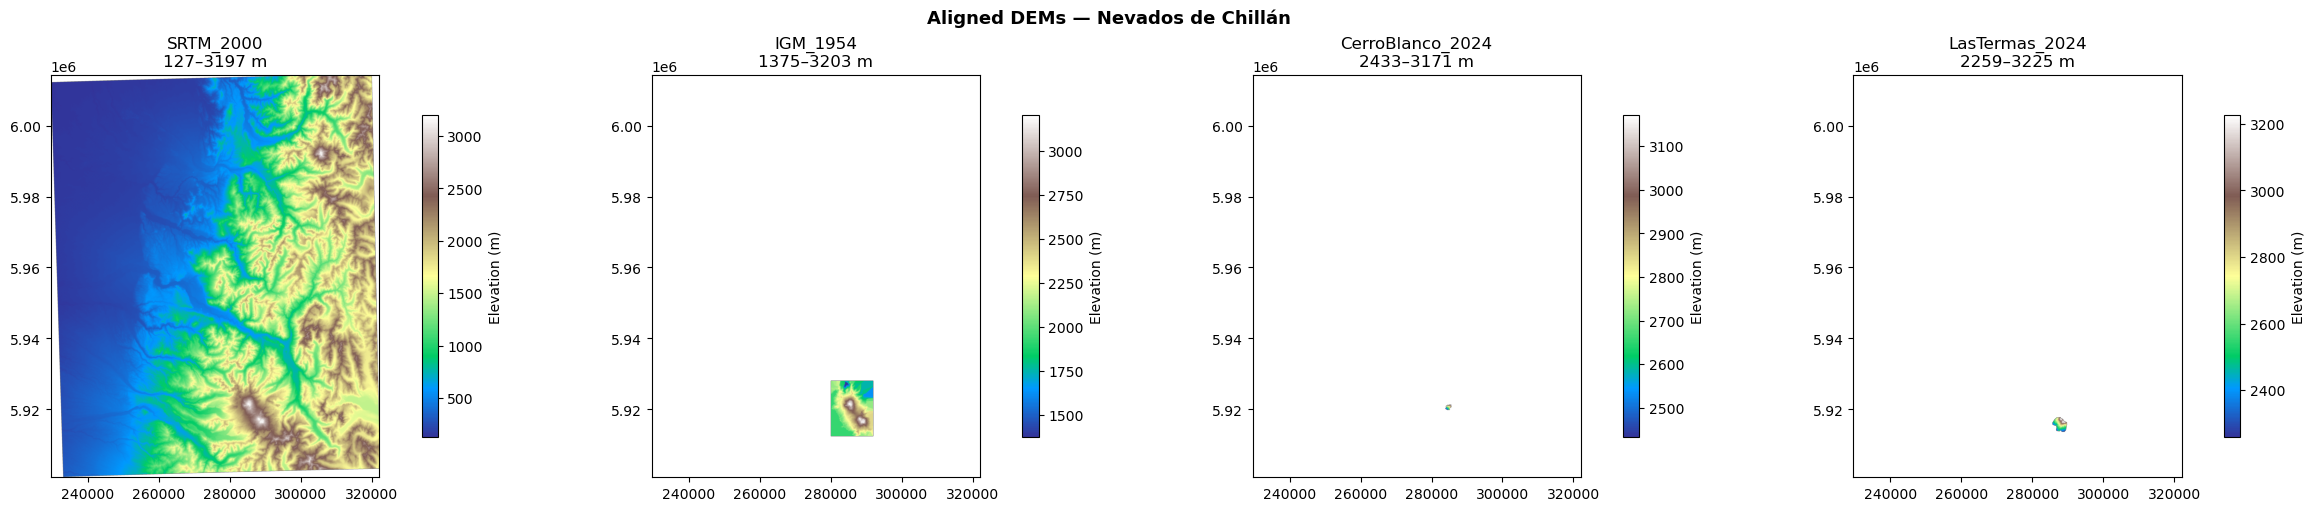

In [27]:
dem_names = ["SRTM_2000", "IGM_1954", "CerroBlanco_2024", "LasTermas_2024"]

fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)

for ax, dem_name in zip(axes, dem_names):
    path = os.path.join("aligned_dems", f"{dem_name}_aligned.tif")
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan
        # Also catch the large float nodata that slips through
        data[data > 1e10] = np.nan
        data[data < -1000] = np.nan
        extent = [src.bounds.left, src.bounds.right,
                  src.bounds.bottom, src.bounds.top]

    im = ax.imshow(data, cmap="terrain", extent=extent, origin="upper")
    plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.8)
    ax.set_title(f"{dem_name}\n{np.nanmin(data):.0f}–{np.nanmax(data):.0f} m")

fig.suptitle("Aligned DEMs — Nevados de Chillán", fontsize=13, fontweight="bold")
plt.show()

In [28]:
for ax, dem_name in zip(axes, DEM_FILES):
    aligned_path = os.path.join(OUTPUT_FOLDER, f"{dem_name}_aligned.tif")
    if not os.path.exists(aligned_path):
        ax.set_title(f"{dem_name}\n(not found)")
        continue
    with rasterio.open(aligned_path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan
        extent = [src.bounds.left, src.bounds.right,
                  src.bounds.bottom, src.bounds.top]
    im = ax.imshow(data, cmap="terrain", extent=extent, origin="upper")
    plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.8)
    ax.set_title(dem_name, fontsize=11)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_22510/2356819533.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 2400x500 with 9 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.8)
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_22510/2356819533.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 2400x500 with 10 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.8)
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_22510/2356819533.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 2400x500 with 11 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.8)
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_22510/2356819533.py:14: UserWarni

<Figure size 640x480 with 0 Axes>

In [29]:
fig.suptitle("Aligned DEMs — Nevados de Chillán", fontsize=13, fontweight="bold")
fig.savefig(os.path.join(OUTPUT_FOLDER, "aligned_dem_overview.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [30]:
print("\nNotebook 1 complete.")
print(f"Aligned DEMs saved to: {OUTPUT_FOLDER}/")
print("Pass aligned_dems/ folder to Notebook 2 for co-registration.")


Notebook 1 complete.
Aligned DEMs saved to: aligned_dems/
Pass aligned_dems/ folder to Notebook 2 for co-registration.


In [31]:
import rasterio

for dem_file in [
    "example_data_Nevados/Nevados_DEMs/CerroBlanco_2024.tif",
    "example_data_Nevados/Nevados_DEMs/LasTermas_2024.tif", 
    "example_data_Nevados/Nevados_DEMs/IGM_1954.tif",
    "example_data_Nevados/Nevados_DEMs/SRTM_2000.tif",
]:
    with rasterio.open(dem_file) as src:
        print(f"{dem_file.split('/')[-1]}: CRS={src.crs}, "
              f"res={src.res}, shape={src.shape}")

CerroBlanco_2024.tif: CRS=EPSG:4326, res=(8.761960000002116e-07, 7.042859999999532e-07), shape=(19371, 21757)
LasTermas_2024.tif: CRS=EPSG:4326, res=(1.8726799999998898e-06, 1.504369999999964e-06), shape=(24839, 24749)
IGM_1954.tif: CRS=EPSG:20049, res=(30.0, 30.0), shape=(522, 399)
SRTM_2000.tif: CRS=EPSG:20049, res=(30.0, 30.0), shape=(3778, 3083)
